## 1. Library Installation

In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pycountry
from countryinfo import CountryInfo as CInfo
import matplotlib.pyplot as plt
import  altair  as  alt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
import warnings

# Suprimir todos los FutureWarning
warnings.simplefilter('ignore', FutureWarning)


## 2. Data Loading & Exploratory Analysis

In [51]:
data = pd.read_csv("https://raw.githubusercontent.com/github/innovationgraph/main/data/languages.csv", delimiter=',')

# Drop colums
data = data.drop(columns=["language_type"])

# Filter EU
data = data[data.iso2_code != "EU"]

# Filter XK = Kosovo
data = data[data.iso2_code != "XK"]

In [52]:
# This will give you the count of rows with NaN values.
nan_rows_count = data.isna().any(axis=1).sum()
print(f"There are {nan_rows_count} rows with NaN values in the dataset.")

There are 57 rows with NaN values in the dataset.


In [53]:
data[data["iso2_code"].isnull()] = "NA"

In [54]:
# Keep the 10 most used programming languages
top_program_lang = programming_languages = [
    "C",
    "C#",
    "C++",
    "Go",
    "Java",
    "JavaScript",
    "PHP",
    "Python",
    "Ruby",
    "TypeScript"
]

data_filter = data[data['language'].isin(top_program_lang)]
data_filter = data_filter.reset_index(drop=True)

In [55]:
data_filter['year_quarter'] = data_filter['year'].astype(str) + '-Q' + data_filter['quarter'].astype(str)
# We reset the index
data_filter = data_filter.reset_index(drop=True)
# Creating a unique identifier
data_filter['unique_id'] = data_filter['iso2_code'] + '-' + data_filter['language']
data_filter

,num_pushers,language,iso2_code,year,quarter,year_quarter,unique_id
0,1734,JavaScript,AE,2020,1,2020-Q1,AE-JavaScript
1,816,Python,AE,2020,1,2020-Q1,AE-Python
2,685,Java,AE,2020,1,2020-Q1,AE-Java
3,377,Ruby,AE,2020,1,2020-Q1,AE-Ruby
4,354,PHP,AE,2020,1,2020-Q1,AE-PHP
...,...,...,...,...,...,...,...
23566,507,TypeScript,ZW,2025,1,2025-Q1,ZW-TypeScript
23567,233,PHP,ZW,2025,1,2025-Q1,ZW-PHP
23568,179,Java,ZW,2025,1,2025-Q1,ZW-Java
23569,150,C,ZW,2025,1,2025-Q1,ZW-C


## 3. Balanced Panel Data

In [56]:
# Create a DataFrame of unique identifiers
iso2_code = pd.DataFrame({'iso2_code': data_filter['iso2_code'].unique()})

# Create a DataFrame of unique identifiers for languages
language = pd.DataFrame({'language': data_filter['language'].unique()})

# Create a DataFrame of all time periods
# time_periods = pd.DataFrame({'year_quarter': range(data_filter['year_quarter'].min(), data_filter['year_quarter'].max() + 1)})
year_quarter = pd.DataFrame({'year_quarter': data_filter['year_quarter'].unique()})

# Create the Cartesian product of unique_ids and time_periods
balanced_panel = iso2_code.merge(language, how='cross').merge(year_quarter, how='cross')

balanced_panel["unique_id"] = balanced_panel["iso2_code"] + "-" +balanced_panel["language"]

# # Merge the balanced panel with the original data
balanced_df = balanced_panel.merge(data_filter, on=['unique_id', 'year_quarter'], how='left')

# # Merge the DataFrames with suffixes
balanced_df = balanced_panel.merge(data_filter, on=['unique_id', 'year_quarter'], how='left', suffixes=('', '_y'))

# # Now, drop the columns with '_y' suffix, which are from the right DataFrame
balanced_df = balanced_df.loc[:, ~balanced_df.columns.str.endswith('_y')]
balanced_df

,iso2_code,language,year_quarter,unique_id,num_pushers,year,quarter
0,AE,JavaScript,2020-Q1,AE-JavaScript,1734,2020,1
1,AE,JavaScript,2020-Q2,AE-JavaScript,2299,2020,2
2,AE,JavaScript,2020-Q3,AE-JavaScript,2366,2020,3
3,AE,JavaScript,2020-Q4,AE-JavaScript,2468,2020,4
4,AE,JavaScript,2021-Q1,AE-JavaScript,2544,2021,1
...,...,...,...,...,...,...,...
34645,GP,Go,2024-Q1,GP-Go,NaN,NaN,NaN
34646,GP,Go,2024-Q2,GP-Go,NaN,NaN,NaN
34647,GP,Go,2024-Q3,GP-Go,NaN,NaN,NaN
34648,GP,Go,2024-Q4,GP-Go,NaN,NaN,NaN


In [57]:
# Function to convert quarter format to integer
def quarter_to_int(quarter_string):
    year, q = quarter_string.split('-')
    year = int(year)
    quarter_number = int(q[1])  # Q1, Q2, Q3, Q4 -> 1, 2, 3, 4
    base_year = 2020  # Adjust based on your balanced_df, or set dynamically
    return 4 * (year - base_year) + quarter_number

# Applying the function
balanced_df['quarter'] = balanced_df['year_quarter'].apply(quarter_to_int)
balanced_df['year'] = balanced_df['year_quarter'].str.split('-').str[0]
balanced_df.loc[balanced_df["num_pushers"].isnull(), "num_pushers"] = 0
balanced_df

,iso2_code,language,year_quarter,unique_id,num_pushers,year,quarter
0,AE,JavaScript,2020-Q1,AE-JavaScript,1734,2020,1
1,AE,JavaScript,2020-Q2,AE-JavaScript,2299,2020,2
2,AE,JavaScript,2020-Q3,AE-JavaScript,2366,2020,3
3,AE,JavaScript,2020-Q4,AE-JavaScript,2468,2020,4
4,AE,JavaScript,2021-Q1,AE-JavaScript,2544,2021,5
...,...,...,...,...,...,...,...
34645,GP,Go,2024-Q1,GP-Go,0,2024,17
34646,GP,Go,2024-Q2,GP-Go,0,2024,18
34647,GP,Go,2024-Q3,GP-Go,0,2024,19
34648,GP,Go,2024-Q4,GP-Go,0,2024,20



## 4. Preprocessing & SDiD Variable Creation

In [58]:
# Define a function that converts country names to ISO2 codes
def country_to_iso2(country_name):
    try:
        # Attempt to get the country's ISO2 code using pycountry
        return pycountry.countries.get(name=country_name).alpha_2
    except AttributeError:
        try:
            # Handle special cases where the country name doesn't exactly match pycountry's database
            special_cases = {
                "Czechia (Czech Republic)": "CZ",
                "Congo (Congo-Brazzaville)": "CG",
                "Holy See": "VA",
                "Timor-Leste (East Timor)": "TL",
                "Ukraine (with certain exceptions)": "UA",
                "Taiwan": "TW",
                "Bolivia": "BO",
                "Tanzania": "TZ",
                "South Korea": "KR",
                "Moldova": "MD",
                "Brunei": "BN"
            }
            return special_cases[country_name]
        except KeyError:
            return None

# Create a list of countries and get their ISO2 codes using the country_to_iso2 function
gpt_countries_list = [
    "Albania", "Algeria", "Andorra", "Angola", "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria",
    "Azerbaijan", "Bahamas", "Bangladesh", "Barbados", "Belgium", "Belize", "Benin", "Bhutan", "Bolivia",
    "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria", "Burkina Faso", "Cabo Verde", "Canada",
    "Chile", "Colombia", "Comoros", "Congo (Congo-Brazzaville)", "Costa Rica", "Côte d'Ivoire", "Croatia", "Cyprus",
    "Czechia", "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "El Salvador", "Estonia", "Fiji",
    "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana", "Greece", "Grenada", "Guatemala", "Guinea",
    "Guinea-Bissau", "Guyana", "Haiti", "Holy See", "Honduras", "Hungary", "Iceland", "India", "Indonesia", "Iraq",
    "Ireland", "Israel", "Italy", "Jamaica", "Japan", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait",
    "Kyrgyzstan", "Latvia", "Lebanon", "Lesotho", "Liberia", "Liechtenstein", "Lithuania", "Luxembourg", "Madagascar",
    "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Marshall Islands", "Mauritania", "Mauritius", "Mexico",
    "Micronesia", "Moldova", "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar", "Namibia",
    "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "North Macedonia", "Norway",
    "Oman", "Pakistan", "Palau", "Palestine, State of", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines",
    "Poland", "Portugal", "Qatar", "Romania", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia",
    "Saint Vincent and the Grenadines", "Samoa", "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal",
    "Serbia", "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "South Africa",
    "South Korea", "Spain", "Sri Lanka", "Suriname", "Sweden", "Switzerland", "Taiwan", "Tanzania", "Thailand",
    "Timor-Leste", "Togo", "Tonga", "Trinidad and Tobago", "Tunisia", "Turkey", "Tuvalu", "Uganda", "Ukraine",
    "United Arab Emirates", "United Kingdom", "United States", "Uruguay", "Vanuatu", "Zambia"
]

gpt_countries_iso = [country_to_iso2(country) for country in gpt_countries_list]

# Add a new column 'gpt_available' with value 1 if the iso2_code is in gpt_countries_iso, otherwise 0
balanced_df["gpt_available"] = balanced_df["iso2_code"].apply(lambda row: 1 if row in gpt_countries_iso else 0)

In [59]:
# Get unique ISO2 country codes from the dataset
countries = data.iso2_code.unique()

def create_populations_dictionary():
    # Initialize the dictionary and define fallback values for known problematic codes
    country_populations = {}
    special_cases = {"MM": 54688774, "PS": 5483450, "ME": 602445, "AD":79824}
    # special_cases = {}
    for country in countries:
        try:
            # Try retrieving population by ISO2 code directly via CInfo
            country_populations.update({country: CInfo(country).info()["population"]})
        except KeyError:
            try:
                # Fallback: look up the official country name, then fetch population
                fallback_name = pycountry.countries.lookup(country).name
                country_populations.update({country: CInfo(fallback_name).info()["population"]})
            except KeyError:
                # As a last resort, use the hard-coded special case value
                print(country)
                country_populations.update({country: special_cases[country]})

    return country_populations

country_populations = create_populations_dictionary()

ME
MM
PS
AD


In [60]:
# Create necessary variables
balanced_df["population"] = balanced_df["iso2_code"].map(country_populations)
# balanced_df["num_pushers_pc"] = (balanced_df["num_pushers"] / balanced_df["population"])*100000
balanced_df.loc[:, "num_pushers_pc"] = (balanced_df["num_pushers"] / balanced_df["population"] * 100000).replace([np.inf, -np.inf], 0).fillna(0).astype("float64")
# balanced_df['gpt_available_post1'] = (balanced_df['quarter'] >= 12).astype(int)
balanced_df.loc[:, "post1"] = (balanced_df["quarter"] >= 12).astype("int8")
balanced_df.loc[:, "post2"] = (balanced_df["quarter"] >= 13).astype("int8")
balanced_df.loc[:, "gpt_available_post1"] = (balanced_df["gpt_available"] & balanced_df["post1"]).astype("int8")
balanced_df.loc[:, "gpt_available_post2"] = (balanced_df["gpt_available"] & balanced_df["post2"]).astype("int8")
balanced_df["Treatment"] = (balanced_df["gpt_available_post1"] * balanced_df["post1"]).astype("int8")
# balanced_df.loc[:, "Treatment"] = balanced_df["gpt_available_post1"].astype("int8")

# Cange Types
balanced_df.loc[:, "year"]          = balanced_df["year"].astype("int16")
balanced_df.loc[:, "quarter"]       = balanced_df["quarter"].astype("int16")
balanced_df.loc[:, "population"]    = balanced_df["population"].astype("int64")
balanced_df.loc[:, "num_pushers"]   = balanced_df["num_pushers"].astype("float64")
balanced_df.loc[:, "gpt_available"] = balanced_df["gpt_available"].clip(0,1).astype("int8")

# Filter years
balanced_df = balanced_df[(balanced_df["quarter"] >= 1) & (balanced_df["quarter"] <= 16)]

In [61]:
balanced_df

,iso2_code,language,year_quarter,unique_id,num_pushers,year,quarter,gpt_available,population,num_pushers_pc,post1,post2,gpt_available_post1,gpt_available_post2,Treatment
0,AE,JavaScript,2020-Q1,AE-JavaScript,1734.0,2020,1,1,9446000,18.356976,0,0,0,0,0
1,AE,JavaScript,2020-Q2,AE-JavaScript,2299.0,2020,2,1,9446000,24.338344,0,0,0,0,0
2,AE,JavaScript,2020-Q3,AE-JavaScript,2366.0,2020,3,1,9446000,25.047639,0,0,0,0,0
3,AE,JavaScript,2020-Q4,AE-JavaScript,2468.0,2020,4,1,9446000,26.127461,0,0,0,0,0
4,AE,JavaScript,2021-Q1,AE-JavaScript,2544.0,2021,5,1,9446000,26.932035,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34640,GP,Go,2022-Q4,GP-Go,0.0,2022,12,0,405739,0.000000,1,0,0,0,0
34641,GP,Go,2023-Q1,GP-Go,0.0,2023,13,0,405739,0.000000,1,1,0,0,0
34642,GP,Go,2023-Q2,GP-Go,0.0,2023,14,0,405739,0.000000,1,1,0,0,0
34643,GP,Go,2023-Q3,GP-Go,0.0,2023,15,0,405739,0.000000,1,1,0,0,0


In [62]:
print(balanced_df.isna().sum())

iso2_code              0
language               0
year_quarter           0
unique_id              0
num_pushers            0
year                   0
quarter                0
gpt_available          0
population             0
num_pushers_pc         0
post1                  0
post2                  0
gpt_available_post1    0
gpt_available_post2    0
Treatment              0
dtype: int64


In [63]:
balanced_df.to_csv("../output/data/data_langs_balanced.csv")

# Map: ChatGPT Availability Worldwide

C:\Users\KARL\AppData\Local\Temp\ipykernel_12124\2812808348.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  balanced_df['iso3_code'] = balanced_df['iso2_code'].apply(iso2_to_iso3)


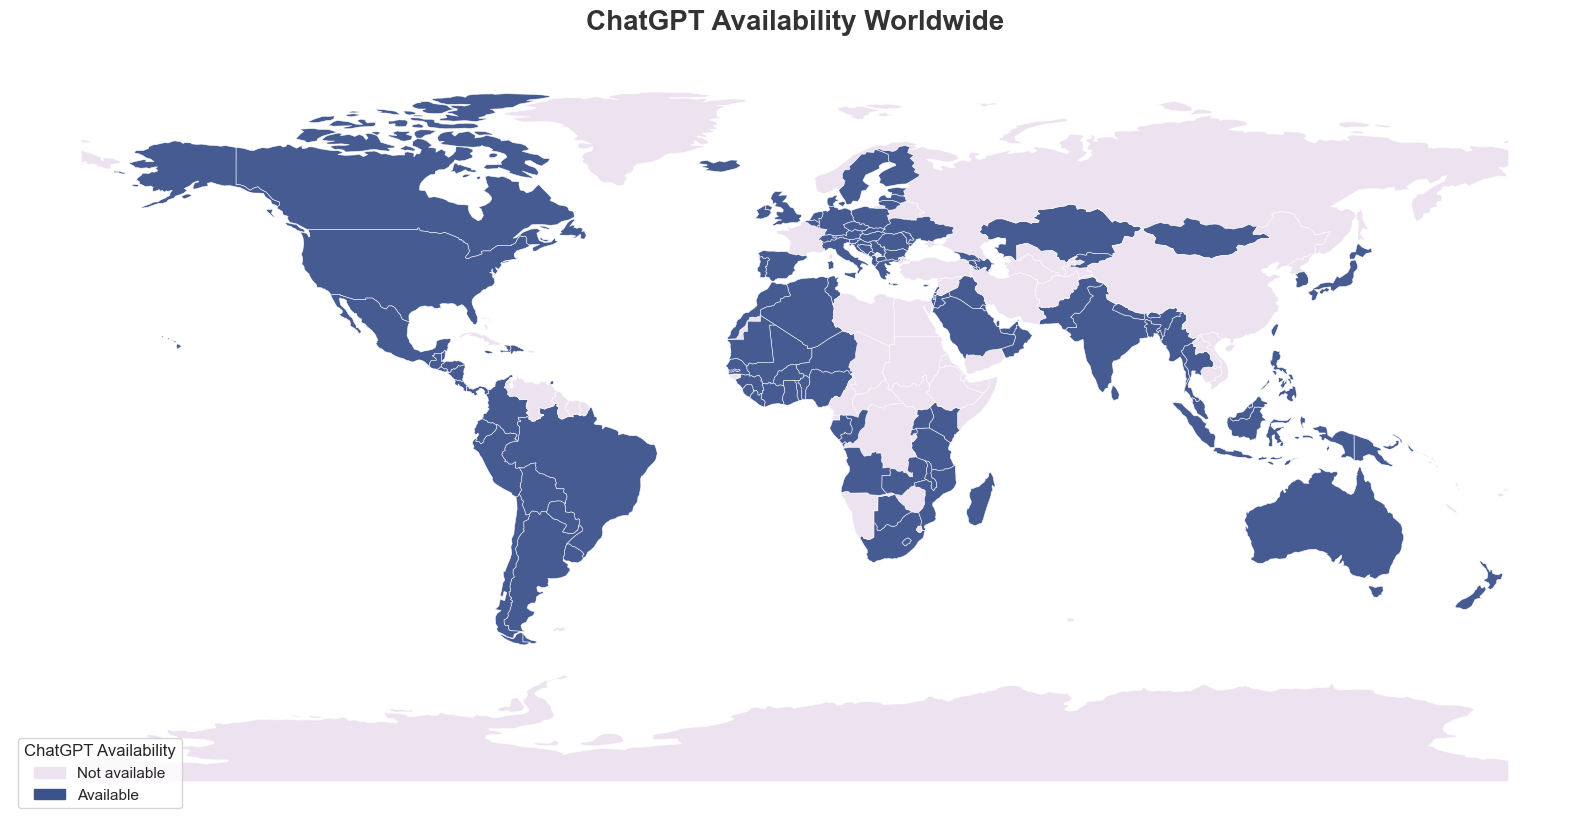

In [64]:
import geopandas as gpd
import pycountry
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1) ISO2 to ISO3 conversion function
def iso2_to_iso3(iso2):
    try:
        return pycountry.countries.get(alpha_2=iso2).alpha_3
    except:
        return None

# 2) Prepare your DataFrame (replace this with your actual data load)
balanced_df['iso3_code'] = balanced_df['iso2_code'].apply(iso2_to_iso3)
balanced_df = balanced_df.dropna(subset=['iso3_code'])
country_gpt = (
    balanced_df
    .groupby('iso3_code', as_index=False)['gpt_available']
    .max()
)

# 3) Load the countries shapefile
shapefile_path = r"F:/Programas/GitHub Desktop/EDA/ne_110m_admin_0_countries.shp"
world = gpd.read_file(shapefile_path)

# 4) Ensure ISO_A3 column is named 'iso_a3'
if 'ISO_A3' in world.columns:
    world = world.rename(columns={'ISO_A3': 'iso_a3'})
elif 'iso_a3' not in world.columns:
    raise ValueError("Shapefile does not contain 'ISO_A3' or 'iso_a3' column.")

# 5) Merge and fill missing values
world = world.merge(country_gpt, how='left', left_on='iso_a3', right_on='iso3_code')
world['gpt_available'] = world['gpt_available'].fillna(0).astype(int)

# 6) Define discrete palette and legend patches
colors = ['#ece2f0', '#3b528b']  # pale purple / dark blue
cmap = ListedColormap(colors)
patches = [
    mpatches.Patch(color=colors[0], label='Not available'),
    mpatches.Patch(color=colors[1], label='Available')
]

# 7) Plot the map
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_facecolor('#f7f7f7')  # light background

world.plot(
    column='gpt_available',
    cmap=cmap,
    edgecolor='white',
    linewidth=0.4,
    ax=ax,
    alpha=0.95
)

# 8) Add custom legend
ax.legend(
    handles=patches,
    loc='lower left',
    frameon=True,
    framealpha=0.8,
    title='ChatGPT Availability',
    title_fontsize=12,
    fontsize=11
)

# 9) Final details
ax.set_title(
    "ChatGPT Availability Worldwide",
    fontsize=20,
    fontweight='bold',
    pad=20,
    color='#333333'
)
ax.axis('off')
plt.tight_layout()
plt.show()


In [65]:
# 1) Save the figure in high resolution BEFORE displaying
output_png = r"F:/Programas/GitHub Desktop/EDA/mapa_chatgpt_hd.png"
fig.savefig(
    output_png,
    dpi=600,               # 600 DPI for ultra HD quality
    bbox_inches='tight',   # trim extra whitespace
    transparent=False      # opaque background
)
print(f"👉 Map saved to: {output_png}")

# 2) (Optional) Display the map on screen
plt.show()


👉 Map saved to: F:/Programas/GitHub Desktop/EDA/mapa_chatgpt_hd.png


In [66]:
# Assume you already have 'world' with the 'gpt_available' column
# and a 'NAME' or 'ADMIN' column for country names.

country_col = 'NAME' if 'NAME' in world.columns else 'ADMIN'

# Compact list of countries WITH ChatGPT
available = (
    world.loc[world['gpt_available'] == 1, country_col]
         .sort_values()
         .tolist()
)
print("Available:")
print(", ".join(available))

# Compact list of countries WITHOUT ChatGPT
not_available = (
    world.loc[world['gpt_available'] == 0, country_col]
         .sort_values()
         .tolist()
)
print("\nNot available:")
print(", ".join(not_available))


Available:
Albania, Algeria, Angola, Argentina, Armenia, Australia, Austria, Azerbaijan, Bangladesh, Belgium, Belize, Benin, Bhutan, Bolivia, Bosnia and Herz., Botswana, Brazil, Brunei, Bulgaria, Burkina Faso, Canada, Chile, Colombia, Congo, Costa Rica, Croatia, Cyprus, Czechia, Côte d'Ivoire, Denmark, Dominican Rep., Ecuador, El Salvador, Estonia, Finland, Gabon, Gambia, Georgia, Germany, Ghana, Greece, Guatemala, Guinea, Haiti, Honduras, Hungary, Iceland, India, Indonesia, Iraq, Ireland, Israel, Italy, Jamaica, Japan, Jordan, Kazakhstan, Kenya, Kuwait, Kyrgyzstan, Latvia, Lebanon, Lesotho, Liberia, Lithuania, Luxembourg, Madagascar, Malawi, Malaysia, Mali, Mauritania, Mexico, Moldova, Mongolia, Montenegro, Morocco, Mozambique, Myanmar, Nepal, Netherlands, New Zealand, Nicaragua, Niger, Nigeria, North Macedonia, Oman, Pakistan, Palestine, Panama, Papua New Guinea, Paraguay, Peru, Philippines, Poland, Portugal, Qatar, Romania, Rwanda, Saudi Arabia, Senegal, Serbia, Sierra Leone, Slovak